A neural network with one hidden layer, built from scratch in NumPy:

- Forward propagation (input -> hidden -> output)
- Manual backpropagation using the chain rule
- Trained on XOR — the classic problem a single layer (logistic regression) can't solve
- Loss curve + decision boundary visualization
- Sanity check against sklearn's MLPClassifier

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# XOR dataset — not linearly separable, requires a hidden layer
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # a is already sigmoid(z), so the derivative is a*(1-a)
    return a * (1 - a)

In [16]:
# Network architecture: 2 inputs -> 4 hidden units -> 1 output
np.random.seed(42)

n_input = 2
n_hidden = 4
n_output = 1

W1 = np.random.randn(n_input, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output) * 0.5
b2 = np.zeros((1, n_output))

In [17]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

In [18]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8  # avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [19]:
def backward(X, y, A1, A2, W2):
    n = X.shape[0]

    # Output layer gradients (sigmoid + BCE collapses to A2 - y, same trick as logistic regression)
    dZ2 = A2 - y
    dW2 = (A1.T @ dZ2) / n
    db2 = np.sum(dZ2, axis=0, keepdims=True) / n

    # Hidden layer gradients — chain rule back through W2 and the hidden sigmoid
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (X.T @ dZ1) / n
    db1 = np.sum(dZ1, axis=0, keepdims=True) / n

    return dW1, db1, dW2, db2

In [20]:
learning_rate = 0.5
epochs = 10000
losses = []

for epoch in range(epochs):
    # 1. Forward pass
    Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)

    # 2. Compute loss
    loss = binary_cross_entropy(y, A2)
    losses.append(loss)

    # 3. Backward pass
    dW1, db1, dW2, db2 = backward(X, y, A1, A2, W2)

    # 4. Update parameters
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, loss = {loss:.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")

Epoch 0, loss = 0.7046
Epoch 1000, loss = 0.5939
Epoch 2000, loss = 0.0283
Epoch 3000, loss = 0.0103
Epoch 4000, loss = 0.0061
Epoch 5000, loss = 0.0043
Epoch 6000, loss = 0.0033
Epoch 7000, loss = 0.0027
Epoch 8000, loss = 0.0023
Epoch 9000, loss = 0.0020

Final loss: 0.0017


In [21]:
_, _, _, predictions = forward(X, W1, b1, W2, b2)
predicted_labels = (predictions > 0.5).astype(int)

print("Input | Target | Predicted Prob | Predicted Label")
for i in range(len(X)):
    print(f"{X[i]}   |   {y[i][0]}    |     {predictions[i][0]:.4f}     |       {predicted_labels[i][0]}")

accuracy = np.mean(predicted_labels == y)
print(f"\nAccuracy: {accuracy*100:.2f}%")

Input | Target | Predicted Prob | Predicted Label
[0 0]   |   0    |     0.0024     |       0
[0 1]   |   1    |     0.9984     |       1
[1 0]   |   1    |     0.9984     |       1
[1 1]   |   0    |     0.0013     |       0

Accuracy: 100.00%


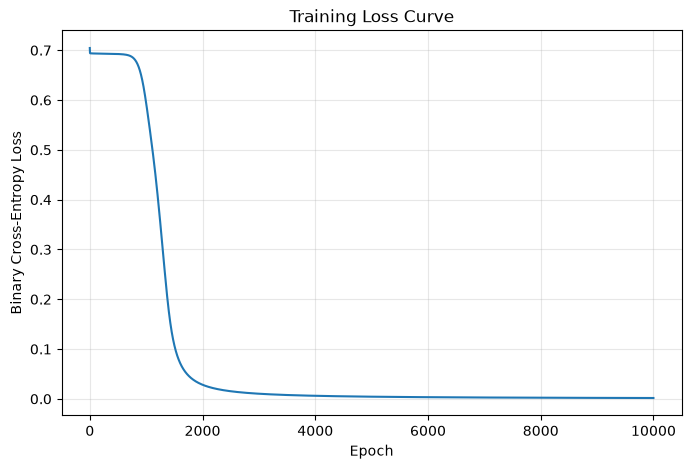

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()

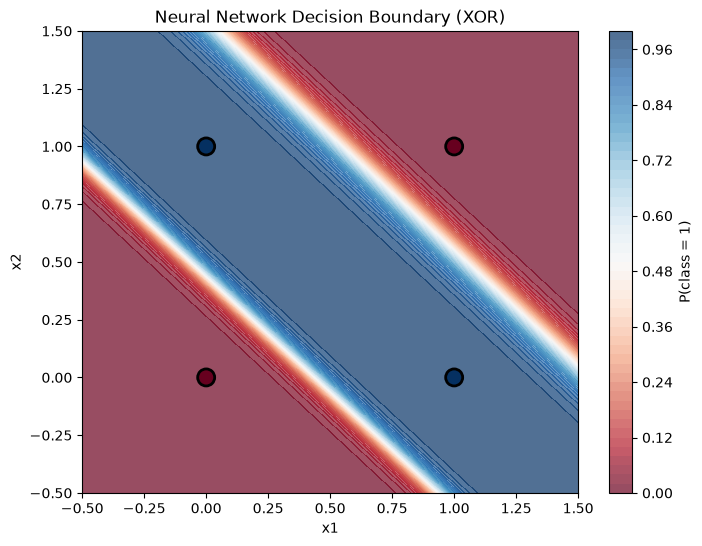

In [23]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

_, _, _, Z = forward(grid, W1, b1, W2, b2)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(class = 1)')
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu', edgecolors='black', s=150, linewidths=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Neural Network Decision Boundary (XOR)')
plt.show()

In [24]:
from sklearn.neural_network import MLPClassifier

sk_model = MLPClassifier(hidden_layer_sizes=(4,), activation='logistic', max_iter=10000, random_state=42)
sk_model.fit(X, y.ravel())

sk_accuracy = sk_model.score(X, y.ravel())
print(f"sklearn MLPClassifier accuracy: {sk_accuracy*100:.2f}%")

sklearn MLPClassifier accuracy: 50.00%
